# Ljungqvist & Sargent (2018), Chapter 7 --- Recursive Competitive Equilibrium: I

Companion notebook to `ls_solutions_ch07.pdf`. Chapter 7 has **7 end-of-chapter exercises**
(printed pp. 244--248). One section per exercise. Every number in the PDF is computed here and
checked by an independent route with an `assert`: `olrp` (Riccati iteration) vs scipy's DARE vs
undetermined coefficients on the Euler equation; the rational-expectations fixed point vs the
planner's regulator vs a damped iteration on $H\mapsto\mathcal M(H)$; `nnash` (stacked Riccati) vs
best-response iteration; grid backward induction vs closed forms (7.6); a grid recursive competitive
equilibrium vs a scalar steady-state root (7.7).

The book's Matlab programs (`olrp.m`, `nnash.m`) are replaced by Python functions. The LQ toolkit
(`olrp`, `dare`, `evaluate`, `howard`, `d_const`) is copied verbatim from `ls_ch05.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are, solve_discrete_lyapunov

plt.rcParams.update({"pdf.fonttype": 42, "font.size": 10})  # TrueType, never Type 3
FIG = "fig/"
np.set_printoptions(precision=5, suppress=True, linewidth=110)


def olrp(beta, A, B, R, Q, H=None, tol=1e-12, maxit=200_000, P0=None):
    """Exercise 5.1(b): solve the discounted regulator with cross term by iterating on the Riccati map.

    beta: discount factor; A (n,n), B (n,k): law of motion x' = Ax + Bu (+ C eps);
    R (n,n), Q (k,k), H (k,n): return -(x'Rx + u'Qu + 2u'Hx); H=None means no cross term.
    Starts from P0 (default zeros). Returns (P, F, iterations); u = -F x.
    Raises RuntimeError if the iteration has not converged after maxit steps.
    """
    n, k = B.shape
    H = np.zeros((k, n)) if H is None else H
    P = np.zeros((n, n)) if P0 is None else P0
    for it in range(1, maxit + 1):
        G = beta * B.T @ P @ A + H
        Pn = R + beta * A.T @ P @ A - G.T @ np.linalg.solve(Q + beta * B.T @ P @ B, G)
        Pn = (Pn + Pn.T) / 2
        if np.max(np.abs(Pn - P)) < tol * max(1.0, np.max(np.abs(Pn))):
            P = Pn
            break
        P = Pn
    else:
        raise RuntimeError("Riccati iteration did not converge")
    F = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
    return P, F, it


def dare(beta, A, B, R, Q, H=None):
    """Independent route: scipy's stabilising DARE solution, discounting absorbed as sqrt(beta)*A, sqrt(beta)*B.

    scipy solves A'XA - X - (A'XB+S)(R+B'XB)^{-1}(B'XA+S') + Q = 0; with S = H' this is equation (1) of 5.1.
    """
    n, k = B.shape
    H = np.zeros((k, n)) if H is None else H
    sb = np.sqrt(beta)
    P = solve_discrete_are(sb * A, sb * B, R, Q, s=H.T)
    F = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
    return P, F


def evaluate(beta, A, B, R, Q, H, F):
    """Value matrix P_F of following u=-Fx forever (policy evaluation, eq. (5.2.10) with cross term)."""
    Rf = R + F.T @ Q @ F - H.T @ F - F.T @ H
    Af = A - B @ F
    return solve_discrete_lyapunov(np.sqrt(beta) * Af.T, Rf)   # P = Rf + beta Af' P Af


def howard(beta, A, B, R, Q, H, F0, tol=1e-12, maxit=100):
    """Howard policy iteration (5.2.10)-(5.2.11), cross term allowed. Returns (P, F, iterations, history of F)."""
    F, hist = F0, [F0]
    for it in range(1, maxit + 1):
        P = evaluate(beta, A, B, R, Q, H, F)
        Fn = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
        hist.append(Fn)
        if np.max(np.abs(Fn - F)) < tol:
            return evaluate(beta, A, B, R, Q, H, Fn), Fn, it, hist
        F = Fn
    raise RuntimeError("policy iteration did not converge")


def d_const(beta, P, C):
    """Constant in v(x) = -x'Px - d for shocks C eps, eq. (5.3.5)."""
    return beta / (1 - beta) * np.trace(P @ C @ C.T)

## Shared: `nnash` --- linear Markov perfect equilibrium (section 7.7)

Player $i$ maximises $-\sum_t\beta^t\{x_t'R_ix_t+u_{it}'Q_iu_{it}\}$ s.t. $x_{t+1}=Ax_t+B_1u_{1t}+B_2u_{2t}$,
taking $u_{-i}=-F_{-i}x$ as given. Backward iteration on (7.7.4)--(7.7.7), discounted: given $(P_1,P_2)$ of
the $(t+1)$ problem, $(F_1,F_2)$ solve the $(k_1+k_2)\times n$ **linear** system
$(Q_1+\beta B_1'P_1B_1)F_1+\beta B_1'P_1B_2F_2=\beta B_1'P_1A$ and symmetrically; then
$P_i\leftarrow R_i+F_i'Q_iF_i+\beta(A-B_1F_1-B_2F_2)'P_i(A-B_1F_1-B_2F_2)$.

In [2]:
def nnash(beta, A, B1, B2, R1, R2, Q1, Q2, tol=1e-12, maxit=100_000):
    """Markov perfect equilibrium of the two-player discounted LQ game (book's nnash.m, no s/w/m terms).

    beta: discount; A (n,n), B1 (n,k1), B2 (n,k2): x' = Ax + B1 u1 + B2 u2;
    R_i (n,n), Q_i (k_i,k_i): player i maximises -sum beta^t (x'R_i x + u_i'Q_i u_i).
    Iterates the stacked Riccati equations (7.7.4)-(7.7.7) backward from P1 = P2 = 0.
    Returns (F1, F2, P1, P2, iterations) with u_i = -F_i x.
    Raises RuntimeError if the iteration has not converged after maxit steps.
    """
    n, k1 = B1.shape
    P1, P2 = np.zeros((n, n)), np.zeros((n, n))
    for it in range(1, maxit + 1):
        M = np.block([[Q1 + beta * B1.T @ P1 @ B1, beta * B1.T @ P1 @ B2],
                      [beta * B2.T @ P2 @ B1, Q2 + beta * B2.T @ P2 @ B2]])
        F = np.linalg.solve(M, np.vstack([beta * B1.T @ P1 @ A, beta * B2.T @ P2 @ A]))
        F1, F2 = F[:k1], F[k1:]
        Ac = A - B1 @ F1 - B2 @ F2
        P1n = R1 + F1.T @ Q1 @ F1 + beta * Ac.T @ P1 @ Ac
        P2n = R2 + F2.T @ Q2 @ F2 + beta * Ac.T @ P2 @ Ac
        dif = max(np.max(abs(P1n - P1)), np.max(abs(P2n - P2)))
        P1, P2 = (P1n + P1n.T) / 2, (P2n + P2n.T) / 2
        if dif < tol * max(1.0, np.max(abs(P1)), np.max(abs(P2))):
            return F1, F2, P1, P2, it
    raise RuntimeError("nnash did not converge")

## Exercise 7.1 --- A competitive firm

Regulator (PDF): $x_t=[y_t,\,Y_t,\,1]'$, $u_t=y_{t+1}-y_t$,
$R_t=(A_0-A_1Y_t)y_t-.5du_t^2=-(x_t'Rx_t+u_t'Qu_t)$ with
$R=\begin{bmatrix}0&A_1/2&-A_0/2\\A_1/2&0&0\\-A_0/2&0&0\end{bmatrix}$, $Q=d/2$,
$A=\begin{bmatrix}1&0&0\\0&H_1&H_0\\0&0&1\end{bmatrix}$, $B=[1,0,0]'$.
Then $y_{t+1}=(1-F_1)y_t-F_2Y_t-F_3$. Closed form (undetermined coefficients on (7.2.7)):
$h_1=1$, $h_2=-\beta A_1H_1/[d(1-\beta H_1)]$, $h_0=\beta(A_0-A_1H_0+dh_2H_0)/[d(1-\beta)]$.
Checks: return mapping at random points; `olrp` vs DARE vs closed form; Euler residual (7.2.7) on a path;
part (d) for $n$ firms.

In [3]:
A0, A1, beta, d = 100.0, 0.05, 0.95, 10.0
H0b, H1b = 95.5, 0.95                       # the beliefs given in part (c)


def firm_lq(H0, H1):
    """Exercise 7.1(b): competitive firm as a regulator, x = [y, Y, 1]', u = y' - y. Returns (A, B, R, Q)."""
    A = np.array([[1, 0, 0], [0, H1, H0], [0, 0, 1.0]])
    B = np.array([[1.0], [0], [0]])
    R = np.array([[0, A1 / 2, -A0 / 2], [A1 / 2, 0, 0], [-A0 / 2, 0, 0]])
    Q = np.array([[d / 2]])
    return A, B, R, Q


def firm_rule(H0, H1):
    """Exercise 7.1(c): solve the firm's regulator with olrp; returns (h0, h1, h2, P) of y' = h0 + h1 y + h2 Y."""
    A, B, R, Q = firm_lq(H0, H1)
    P, F, _ = olrp(beta, A, B, R, Q)
    return -F[0, 2], 1 - F[0, 0], -F[0, 1], P


def firm_rule_closed(H0, H1):
    """Independent route: undetermined coefficients on the Euler equation (7.2.7) (stable root h1 = 1)."""
    h2 = -beta * A1 * H1 / (d * (1 - beta * H1))
    h0 = beta * (A0 - A1 * H0 + d * h2 * H0) / (d * (1 - beta))
    return h0, 1.0, h2


A, B, R, Q = firm_lq(H0b, H1b)
rng = np.random.default_rng(7)
for _ in range(5):                                        # the quadratic form is the firm's return
    y, Y, u = rng.normal(size=3) * 50
    x = np.array([y, Y, 1.0])
    assert np.isclose(-(x @ R @ x + Q[0, 0] * u**2), (A0 - A1 * Y) * y - .5 * d * u**2)

h0, h1, h2, P = firm_rule(H0b, H1b)
Pd, Fd = dare(beta, A, B, R, Q)
hc = firm_rule_closed(H0b, H1b)
assert np.allclose([h0, h1, h2], hc, atol=1e-9)
assert np.allclose([-Fd[0, 2], 1 - Fd[0, 0], -Fd[0, 1]], hc, atol=1e-8)
assert abs(P[0, 0]) < 1e-12                      # value is linear in own output y
print(f"h0 = {h0:.6f}, h1 = {h1:.6f}, h2 = {h2:.6f}")
print("P =\n", P)

# Euler equation (7.2.7) along a path generated by the rule and the perceived law
y, Y, ys, Ys = 10.0, 1500.0, [], []
for t in range(60):
    ys.append(y); Ys.append(Y)
    y, Y = h0 + h1 * y + h2 * Y, H0b + H1b * Y
ys, Ys = np.array(ys), np.array(Ys)
res = -d * (ys[1:-1] - ys[:-2]) + beta * (A0 - A1 * Ys[1:-1] + d * (ys[2:] - ys[1:-1]))
assert np.max(abs(res)) < 1e-8
print("max |Euler residual| =", np.max(abs(res)))

# (d) n identical firms: Y = n y  =>  Y' = n h0 + (h1 + n h2) Y
for n in (1, 10):
    y = 37.0; Y = n * y
    Yn = n * (h0 + h1 * y + h2 * Y)
    assert np.isclose(Yn, n * h0 + (h1 + n * h2) * Y)
    print(f"n = {n:2d}: actual law  Y' = {n*h0:.4f} + {h1 + n*h2:.6f} Y")

h0 = 96.948718, h1 = 1.000000, h2 = -0.046282
P =
 [[      0.            0.25641    -534.74359]
 [      0.25641      -0.07509     163.72056]
 [   -534.74359     163.72056 -358775.95606]]
max |Euler residual| = 5.559286364587024e-11
n =  1: actual law  Y' = 96.9487 + 0.953718 Y
n = 10: actual law  Y' = 969.4872 + 0.537179 Y


## Exercise 7.2 --- Rational expectations

$\mathcal M(H_0,H_1)=(h_0(H),\,h_1+h_2(H))$ with $n=1$. Fixed point: $H_1$ is the stable root of
$d\beta H_1^2-[d(1+\beta)+\beta A_1]H_1+d=0$ and $H_0=\beta A_0/[d(1-\beta)+\beta A_1+\beta d(1-H_1)]$.
Checks: each candidate pair mapped through `olrp`; the fixed point from the quadratic; the Jacobian of
$\mathcal M$ by finite differences; part (b)'s algorithm run (not asked, but it verifies the description)
undamped and damped.

(i)   H = (94.0888, 0.9211)  ->  M(H) = (118.46676003, 0.9649855948)   gap = 2.44e+01
(ii)  H = (93.22, 0.9433)  ->  M(H) = (104.73643672, 0.9568605883)   gap = 1.15e+01
(iii) H = (95.08187459215024, 0.95245906270392)  ->  M(H) = (95.08187459, 0.9524590627)   gap = 1.28e-10
roots of the quadratic: [0.95246 1.10517]  (product = 1/beta: 1.0526315789473684 )
REE: H0 = 95.08187459215, H1 = 0.95245906270392; implied steady state H0/(1-H1) = 2000.000000 = A0/A1


eigenvalues of dM/dH at the REE: -0.998278, -0.524505


gamma = 1.0: distance after 150 iterations = 3.43e+00


gamma = 0.5: distance after 150 iterations = 8.64e-11


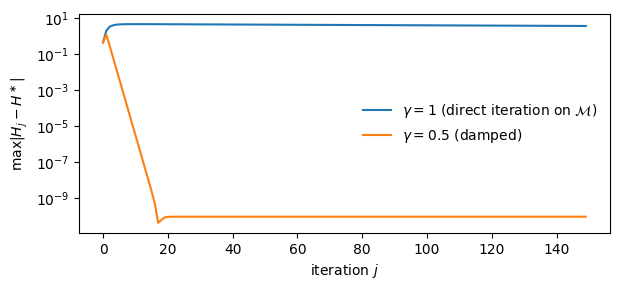

In [4]:
def M_map(H):
    """Exercise 7.2: perceived law (H0, H1) -> actual law (n h0, h1 + n h2), n = 1, via olrp (program of 7.1)."""
    h0, h1, h2, _ = firm_rule(*H)
    return np.array([h0, h1 + h2])


cands = {"(i)": (94.0888, .9211), "(ii)": (93.22, .9433), "(iii)": (95.08187459215024, .95245906270392)}
for k, H in cands.items():
    MH = M_map(H)
    print(f"{k:5s} H = {H}  ->  M(H) = ({MH[0]:.8f}, {MH[1]:.10f})   gap = {np.max(abs(MH - H)):.2e}")
assert np.max(abs(M_map(cands["(iii)"]) - cands["(iii)"])) < 1e-8
assert all(np.max(abs(M_map(cands[k]) - cands[k])) > 1 for k in ("(i)", "(ii)"))

# independent route: closed form of the fixed point
roots = np.sort(np.roots([d * beta, -(d * (1 + beta) + beta * A1), d]).real)
H1s = roots[0]
H0s = beta * A0 / (d * (1 - beta) + beta * A1 + beta * d * (1 - H1s))
print("roots of the quadratic:", roots, " (product = 1/beta:", roots.prod(), ")")
print(f"REE: H0 = {H0s:.11f}, H1 = {H1s:.14f}; implied steady state H0/(1-H1) = {H0s/(1-H1s):.6f} = A0/A1")
assert np.allclose([H0s, H1s], cands["(iii)"], atol=1e-10) and np.isclose(H0s / (1 - H1s), A0 / A1)

# Jacobian of M at the fixed point: M1 depends only on H1, so dM/dH is triangular; diagonal in closed form
j00 = beta * (-A1 + d * (H1s - 1)) / (d * (1 - beta))
j11 = -beta * A1 / (d * (1 - beta * H1s)**2)
eps, Hs = 1e-5, np.array([H0s, H1s])
jd = [(M_map(Hs + eps * e)[i] - M_map(Hs - eps * e)[i]) / (2 * eps) for i, e in enumerate(np.eye(2))]
assert np.allclose(jd, [j00, j11], atol=1e-5)
assert abs(M_map(Hs + [0, eps])[0] - M_map(Hs)[0]) > 0 and abs(M_map(Hs + [eps, 0])[1] - M_map(Hs)[1]) < 1e-12
print(f"eigenvalues of dM/dH at the REE: {j00:.6f}, {j11:.6f}")

# (b) the algorithm: H <- (1-g) H + g M(H), from the beliefs of 7.1(c)
paths = {}
for g in (1.0, 0.5):
    H, err = np.array([H0b, H1b]), []
    for j in range(150):
        err.append(np.max(abs(H - Hs)))
        H = (1 - g) * H + g * M_map(H)
    paths[g] = err
    print(f"gamma = {g}: distance after 150 iterations = {err[-1]:.2e}")
assert paths[0.5][-1] < 1e-8 and paths[1.0][-1] > 1e-2
fig, ax = plt.subplots(figsize=(6.3, 3.0))
for g, lab in ((1.0, r"$\gamma=1$ (direct iteration on $\mathcal{M}$)"), (0.5, r"$\gamma=0.5$ (damped)")):
    ax.semilogy(np.maximum(paths[g], 1e-16), label=lab)
ax.set_xlabel("iteration $j$"); ax.set_ylabel(r"$\max|H_j-H^\ast|$"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG + "ls07_ree_iteration.pdf"); plt.show()

## Exercise 7.3 --- Maximizing welfare

Planner's regulator: $x=[Y,1]'$, $u=Y'-Y$, $R=\begin{bmatrix}A_1/2&-A_0/2\\-A_0/2&0\end{bmatrix}$, $Q=d/2$,
$A=I_2$, $B=[1,0]'$; $Y_{t+1}=(1-F_1)Y_t-F_2$. Checks: $S_t$ by numerical quadrature vs the quadratic form;
`olrp` vs DARE vs the REE of 7.2.

In [5]:
from scipy.integrate import quad

def planner_lq(a1):
    """Regulator for max sum beta^t [A0 Y - (a1/2) Y^2 - .5 d u^2], x = [Y, 1]', u = Y' - Y.
    a1 = A1: planner (7.3); a1 = 2 A1: monopolist (7.4)."""
    return np.eye(2), np.array([[1.0], [0]]), np.array([[a1 / 2, -A0 / 2], [-A0 / 2, 0]]), np.array([[d / 2]])

A, B, R, Q = planner_lq(A1)
for _ in range(5):
    Y, u = rng.uniform(0, 2000), rng.normal() * 30
    S_quad = quad(lambda z: A0 - A1 * z, 0, Y)[0] - .5 * d * u**2
    x = np.array([Y, 1.0])
    assert np.isclose(S_quad, -(x @ R @ x + Q[0, 0] * u**2))
P, F, it = olrp(beta, A, B, R, Q)
Pd, Fd = dare(beta, A, B, R, Q)
s0, s1 = -F[0, 1], 1 - F[0, 0]
assert np.allclose(F, Fd, atol=1e-8) and np.allclose([s0, s1], [H0s, H1s], atol=1e-8)
print(f"planner: Y' = {s0:.11f} + {s1:.14f} Y   ({it} Riccati steps);  P =\n", P)

planner: Y' = 95.08187459215 + 0.95245906270392 Y   (496 Riccati steps);  P =
 [[      0.2627     -525.40937]
 [   -525.40937 -949181.25406]]


## Exercise 7.4 --- Monopoly

Same regulator with $A_1/2\to A_1$ in $R$. Closed form: $s_1$ = stable root of
$d\beta z^2-[d(1+\beta)+2\beta A_1]z+d=0$, $s_0=(1-s_1)A_0/(2A_1)$.

In [6]:
A, B, R, Q = planner_lq(2 * A1)
P, F, _ = olrp(beta, A, B, R, Q)
Pd, Fd = dare(beta, A, B, R, Q)
m0, m1 = -F[0, 1], 1 - F[0, 0]
z = np.sort(np.roots([d * beta, -(d * (1 + beta) + 2 * beta * A1), d]).real)[0]
assert np.allclose(F, Fd, atol=1e-8) and np.isclose(m1, z) and np.isclose(m0, (1 - z) * A0 / (2 * A1))
print(f"monopoly: Y' = {m0:.6f} + {m1:.6f} Y ; steady state {m0/(1-m1):.4f} (planner {s0/(1-s1):.4f})")
print("P =\n", P)

monopoly: Y' = 73.472944 + 0.926527 Y ; steady state 1000.0000 (planner 2000.0000)
P =
 [[      0.41736    -417.36472]
 [   -417.36472 -582635.27981]]


## Exercise 7.5 --- Duopoly

$x=[1,y_1,y_2]'$, $u_i=y_{i,t+1}-y_{it}$, $R_1=\begin{bmatrix}0&-A_0/2&0\\-A_0/2&A_1&A_1/2\\0&A_1/2&0\end{bmatrix}$,
$R_2$ symmetric, $Q_i=d/2$, $A=I_3$, $B_1=e_2$, $B_2=e_3$. Checks: return mapping; `nnash` vs best-response
iteration (each best response by `olrp`); each $P_i$ solves its own player's Riccati equation given the rival's
rule (scipy DARE); symmetry. Figure: industry output under the three market structures.

nnash: 487 iterations
F1 = [[-65.27422   0.06708   0.02423]]
F2 = [[-65.27422   0.02423   0.06708]]

best-response iteration agrees after 12 rounds
MPE rule: y_i' = 65.27422 + 0.93292 y_i + -0.02423 y_-i ;  eig(A - B1F1 - B2F2) = [0.95716 0.90869 1.     ]
steady state: y_i = 714.9017, industry 1429.8035, price 28.5098; static Cournot industry 1333.3333
symmetric industry law: Y' = 130.54844 + 0.908695 Y


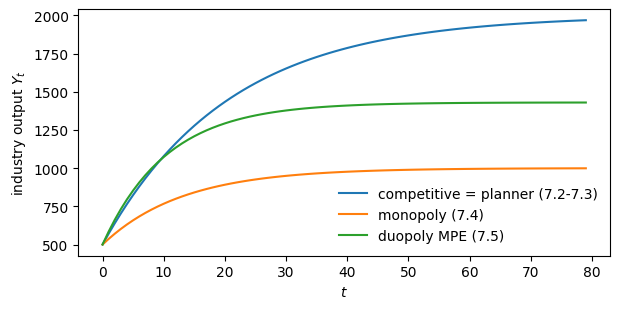

In [7]:
A = np.eye(3); B1 = np.array([[0], [1.0], [0]]); B2 = np.array([[0], [0], [1.0]])
R1 = np.array([[0, -A0 / 2, 0], [-A0 / 2, A1, A1 / 2], [0, A1 / 2, 0]])
R2 = np.array([[0, 0, -A0 / 2], [0, 0, A1 / 2], [-A0 / 2, A1 / 2, A1]])
Qd = np.array([[d / 2]])
for _ in range(5):
    y1, y2, u1 = rng.normal(size=3) * 100
    x = np.array([1.0, y1, y2])
    assert np.isclose(-(x @ R1 @ x + Qd[0, 0] * u1**2), (A0 - A1 * (y1 + y2)) * y1 - .5 * d * u1**2)

F1, F2, P1, P2, it = nnash(beta, A, B1, B2, R1, R2, Qd, Qd)
print(f"nnash: {it} iterations\nF1 = {F1}\nF2 = {F2}")

# independent route: best-response iteration on infinite-horizon problems
G1, G2 = np.zeros((1, 3)), np.zeros((1, 3))
for j in range(500):
    _, G1n, _ = olrp(beta, A - B2 @ G2, B1, R1, Qd)
    _, G2n, _ = olrp(beta, A - B1 @ G1n, B2, R2, Qd)
    dif = max(np.max(abs(G1n - G1)), np.max(abs(G2n - G2))); G1, G2 = G1n, G2n
    if dif < 1e-10: break
assert np.allclose(G1, F1, atol=1e-7) and np.allclose(G2, F2, atol=1e-7)
Pc1, Fc1 = dare(beta, A - B2 @ F2, B1, R1, Qd)          # P1 is player 1's optimum given F2
assert np.allclose(Fc1, F1, atol=1e-8) and np.allclose(Pc1, P1, rtol=1e-7, atol=1e-5)
assert np.allclose(F1[0, [0, 1, 2]], F2[0, [0, 2, 1]])   # symmetry
print(f"best-response iteration agrees after {j+1} rounds")

Ac = A - B1 @ F1 - B2 @ F2
f0, f1, f2 = Ac[1, 0], Ac[1, 1], Ac[1, 2]
yss = f0 / (1 - f1 - f2)
print(f"MPE rule: y_i' = {f0:.5f} + {f1:.5f} y_i + {f2:.5f} y_-i ;  eig(A - B1F1 - B2F2) = {np.linalg.eigvals(Ac).real}")
print(f"steady state: y_i = {yss:.4f}, industry {2*yss:.4f}, price {A0 - A1*2*yss:.4f}; "
      f"static Cournot industry {2*A0/(3*A1):.4f}")
assert np.isclose(yss, np.linalg.solve(np.eye(2) - Ac[1:, 1:], Ac[1:, 0])[0])
print(f"symmetric industry law: Y' = {2*f0:.5f} + {f1+f2:.6f} Y")

# industry output paths from Y0 = 500 (y_i0 = 250)
T = 80
paths = {"competitive = planner (7.2-7.3)": [500.0], "monopoly (7.4)": [500.0]}
for t in range(T - 1):
    paths["competitive = planner (7.2-7.3)"].append(s0 + s1 * paths["competitive = planner (7.2-7.3)"][-1])
    paths["monopoly (7.4)"].append(m0 + m1 * paths["monopoly (7.4)"][-1])
x, dp = np.array([1.0, 250.0, 250.0]), []
for t in range(T):
    dp.append(x[1] + x[2]); x = Ac @ x
paths["duopoly MPE (7.5)"] = dp
fig, ax = plt.subplots(figsize=(6.3, 3.2))
for lab, p in paths.items():
    ax.plot(p, label=lab)
ax.set_xlabel("$t$"); ax.set_ylabel("industry output $Y_t$"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG + "ls07_market_structures.pdf"); plt.show()

## Exercise 7.6 --- Self-control

Illustration with $u=\ln c$, $f(k)=\bar A k^\alpha$ (parameters chosen: $\bar A=1$, $\alpha=.36$, $\beta=.96$, $\delta=.6$, $T=10$).
Closed form (PDF): $W_j(k)=a_j\ln k+\text{const}$, $a_0=\alpha$, $a_{j+1}=\alpha(1+\beta a_j)$; the self with $j+1$
periods to go saves $s=\beta\delta a_j/(1+\beta\delta a_j)$ of $f(k)$; under commitment the dates $t\ge1$ save
$\beta a_j/(1+\beta a_j)$ and date 0 saves the MPE rate. Checks: the functional equations of part (b) and the
commitment Bellman equations of part (c) iterated on a grid with numerical maximisation; self 0's welfare.

a_j: [0.36    0.48442 0.52741 0.54227 0.54741 0.54918 0.5498  0.55001 0.55008 0.55011 0.55012]
MPE saving rates by date:        [0.24062 0.24061 0.24059 0.24052 0.24031 0.23972 0.23801 0.23301 0.21815 0.17175 0.     ]
commitment saving rates by date: [0.24062 0.34558 0.34555 0.34547 0.34521 0.34448 0.34236 0.33613 0.31742 0.25684 0.     ]
self-0 welfare: MPE -5.894380 < commitment -5.713974


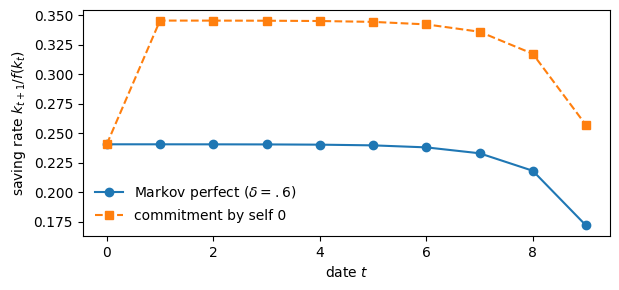

In [8]:
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar

Abar, alpha, b6, delta, T6 = 1.0, 0.36, 0.96, 0.6, 10
f = lambda k: Abar * k**alpha

a = [alpha]
for j in range(T6):
    a.append(alpha * (1 + b6 * a[-1]))
a = np.array(a)
s_mpe = np.array([b6 * delta * a[T6 - t - 1] / (1 + b6 * delta * a[T6 - t - 1]) for t in range(T6)] + [0.0])
s_com = np.array([s_mpe[0]] + [b6 * a[T6 - t - 1] / (1 + b6 * a[T6 - t - 1]) for t in range(1, T6)] + [0.0])

lk = np.linspace(np.log(1e-4), np.log(5.0), 120); kg = np.exp(lk)


def backward(weight):
    """Iterate V_{j+1}(k) = max_c {ln c + weight(j) W_j(k')}, W_{j+1}(k) = ln c_{j+1} + b6 W_j(k'), W_0 = ln f(k).

    weight(j) = b6*delta for every j gives the MPE of part (b); weight = b6 for the selves at t >= 1 and
    b6*delta for self 0 (j = T6-1) gives the commitment Bellman equations of part (c) (J_j = W_j).
    Returns the saving rates s[j][i] of the self with j+1 periods to go at grid point k_i."""
    W = np.log(f(kg)); S = []
    for j in range(T6):
        Wsp = CubicSpline(lk, W)
        sj, Wn = np.empty_like(kg), np.empty_like(kg)
        for i, k in enumerate(kg):
            obj = lambda s: -(np.log((1 - s) * f(k)) + weight(j) * Wsp(np.log(s * f(k))))
            s = minimize_scalar(obj, bounds=(1e-6, 1 - 1e-6), method="bounded", options={"xatol": 1e-11}).x
            sj[i] = s; Wn[i] = np.log((1 - s) * f(k)) + b6 * Wsp(np.log(s * f(k)))
        S.append(sj); W = Wn
    return S

S_mpe = backward(lambda j: b6 * delta)
S_com = backward(lambda j: b6 * delta if j == T6 - 1 else b6)
for t in range(T6):
    j = T6 - t - 1
    assert np.max(abs(S_mpe[j] - s_mpe[t])) < 1e-6 and np.max(abs(S_com[j] - s_com[t])) < 1e-6
print("a_j:", a)
print("MPE saving rates by date:       ", s_mpe)
print("commitment saving rates by date:", s_com)
assert np.isclose(s_mpe[0], s_com[0]) and np.all(s_mpe[1:T6] < s_com[1:T6])


def self0_welfare(s, k0=0.2):
    """Self 0's criterion u(c_0) + delta sum_{j>=1} beta^j u(c_j) along the path generated by saving rates s."""
    k, W = k0, 0.0
    for t in range(T6 + 1):
        c = (1 - s[t]) * f(k); W += np.log(c) * (1 if t == 0 else delta * b6**t); k = s[t] * f(k)
    return W

w_m, w_c = self0_welfare(s_mpe), self0_welfare(s_com)
print(f"self-0 welfare: MPE {w_m:.6f} < commitment {w_c:.6f}")
assert w_c > w_m

fig, ax = plt.subplots(figsize=(6.3, 3.0))
ax.plot(range(T6), s_mpe[:T6], "o-", label=r"Markov perfect ($\delta=.6$)")
ax.plot(range(T6), s_com[:T6], "s--", label="commitment by self 0")
ax.set_xlabel("date $t$"); ax.set_ylabel(r"saving rate $k_{t+1}/f(k_t)$"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG + "ls07_selfcontrol.pdf"); plt.show()

## Exercise 7.7 --- Equilibrium search

Illustration (parameters chosen): $\beta=.95$, $\lambda=.05$, $F$ uniform on $[0,B]$ with $B=1$, $c=2$.
With $\kappa\equiv1-\beta(1-\lambda)$: $E(w,U)=w/\kappa+e(U)$, $e(U)=\beta[(1-\lambda)e(U')+\lambda V(U')]$,
$\bar w(U)=\kappa[c(U)+\beta V(U')-e(U)]$, $V(U)=c(U)+\beta V(U')+\kappa^{-1}\int_{\bar w}^{B}(w-\bar w)dF$,
$\phi(U)=1-F(\bar w(U))$, $U'=G(U)$. The RCE is computed by iterating $G\leftarrow(1-\gamma)G+\gamma G_A$ on a grid.
Independent route: at a steady state $U_s=G(U_s)$ the problem is a scalar McCall problem;
$\bar w_s$ solves $\bar w=\kappa c+\beta(1-\lambda)[c+(B-\bar w)^2/(2B\kappa)]$ and $U_s=\lambda/(\lambda+\phi_s)$.

RCE found after 68 outer iterations; wbar(U) ranges over [0.6663, 0.9870]
steady state: grid RCE U = 0.167051, wbar = 0.750691; scalar U = 0.167051, wbar = 0.750691, phi = 0.249309, c(U) = 0.463024
slope of G at the steady state: 0.7837
alternative timing steady state U = 0.179603
U path from 0.4: [0.4    0.3712 0.3441 0.3188 0.2958 0.2751 0.2568 0.241 ]


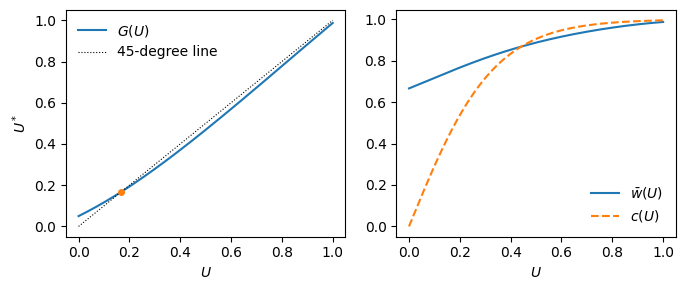

In [9]:
from scipy.optimize import brentq

b7, lam, Bw, cbar = 0.95, 0.05, 1.0, 2.0
kap = 1 - b7 * (1 - lam)
cU = lambda U: cbar * (1 / (1 + np.exp(-6 * U)) - .5)
Ug = np.linspace(0, 1, 1001)


def worker(G, V, e):
    """Given the perceived law U' = G(U) on the grid, solve the worker's Bellman equations by iteration
    (a contraction of modulus b7 for fixed G), warm-started at (V, e). Returns (V, e, wbar) on the grid."""
    for _ in range(5000):
        VG, eG = np.interp(G, Ug, V), np.interp(G, Ug, e)
        wb = np.clip(kap * (cU(Ug) + b7 * VG - eG), 0, Bw)
        Vn = cU(Ug) + b7 * VG + (Bw - wb)**2 / (2 * Bw * kap)
        en = b7 * ((1 - lam) * eG + lam * VG)
        dif = max(np.max(abs(Vn - V)), np.max(abs(en - e))); V, e = Vn, en
        if dif < 1e-12: break
    return V, e, wb


G, V, e = Ug.copy(), np.zeros_like(Ug), np.zeros_like(Ug)
for it in range(2000):
    V, e, wb = worker(G, V, e)
    GA = lam * (1 - Ug) + (wb / Bw) * Ug              # U* = lam (1-U) + (1 - phi(U)) U,  1 - phi = F(wbar)
    dif = np.max(abs(GA - G)); G = 0.5 * G + 0.5 * GA
    if dif < 1e-10: break
assert dif < 1e-10 and wb.min() > 0 and wb.max() < Bw     # interior reservation wages on the whole grid
assert np.all(np.diff(wb) > 0) and np.all(np.diff(G) > 0)  # wbar(U) and G(U) increasing
print(f"RCE found after {it+1} outer iterations; wbar(U) ranges over [{wb.min():.4f}, {wb.max():.4f}]")

Us_grid = brentq(lambda U: np.interp(U, Ug, G) - U, 0.01, 0.9)
# scalar steady state
wss = lambda c: brentq(lambda w: w - kap * c - b7 * (1 - lam) * (c + (Bw - w)**2 / (2 * Bw * kap)), 0, Bw)
Us = brentq(lambda U: U - lam / (lam + 1 - wss(cU(U)) / Bw), 1e-4, 1)
ws = wss(cU(Us))
print(f"steady state: grid RCE U = {Us_grid:.6f}, wbar = {np.interp(Us_grid, Ug, wb):.6f};"
      f" scalar U = {Us:.6f}, wbar = {ws:.6f}, phi = {1-ws/Bw:.6f}, c(U) = {cU(Us):.6f}")
assert abs(Us_grid - Us) < 1e-4 and abs(np.interp(Us, Ug, wb) - ws) < 1e-4
# uniqueness of the steady state on (0,1)
Uc = np.linspace(1e-4, 1 - 1e-4, 4001)
gap = np.array([U - lam / (lam + 1 - wss(cU(U)) / Bw) for U in Uc])
assert np.sum(np.sign(gap[1:]) != np.sign(gap[:-1])) == 1
print(f"slope of G at the steady state: {(np.interp(Us+1e-3, Ug, G) - np.interp(Us-1e-3, Ug, G))/2e-3:.4f}")
# reading check: exact accounting with new hires exposed to firing, U* = lam(1-U+phi U) + (1-phi)U
Us2 = brentq(lambda U: U - lam / (lam + (1 - lam) * (1 - wss(cU(U)) / Bw)), 1e-4, 1)
print(f"alternative timing steady state U = {Us2:.6f}")
Upath = [0.4]
for t in range(60):
    Upath.append(float(np.interp(Upath[-1], Ug, G)))
assert abs(Upath[-1] - Us) < 1e-3
print("U path from 0.4:", np.round(Upath[:8], 4))

fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.0))
axs[0].plot(Ug, G, label="$G(U)$"); axs[0].plot(Ug, Ug, "k:", lw=.8, label="45-degree line")
axs[0].plot(Us, Us, "o", ms=4); axs[0].set_xlabel("$U$"); axs[0].set_ylabel("$U^*$"); axs[0].legend(frameon=False)
axs[1].plot(Ug, wb, label=r"$\bar w(U)$"); axs[1].plot(Ug, cU(Ug), "--", label="$c(U)$")
axs[1].set_xlabel("$U$"); axs[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG + "ls07_search.pdf"); plt.show()